# Vectors

In [9]:
import numpy as np
import matplotlib.pyplot as plt

## Basics

Vector is a list of numbers. For example $\langle12.12, 14, 54.34, 23\rangle$ is a 4-element vector over the field of real numbers. Set of all 4-element vector is represented as $R^{4}$. We can use python list to represent such vectors.

In [1]:
v = [12.12, 14, 54.34, 23]

Vectors can be represented as functions too. For the above example, we can represent the vector as a function as following:
$$
F(0) = 12.12\\
F(1) = 14\\
F(2) = 54.34\\
F(3) = 23
$$
We can use python dictionaries to represent such functions.

In [2]:
V = {
    0: 12.12,
    1: 14,
    2: 54.34,
    3: 23
}

A vector most of whose entries are 0 is called a *sparse vector*. If more than $k$ of entries are non-zero, we call it *k-sparsed* vector, which takes space proportional to $k$. However, most signals like images, sounds, etc, are not sparse.

Finally, there are other vectors like bag of words where all the words in a document and their frequencies are represented by a vector, binary strings, probability distributions, images, and so many things. In general we can represent anything that has a mapping to real numbers. For example, in case of images, pixel density of each grid is mapped to a pixel value.

## Addition & Translation

In [6]:
def addVec(u, v):
    """
    Adds the given vectors and returns a new one.
    """
    assert len(u) == len(v), "Vectors have unequal lengths!"
    
    return [u[i] + v[i] for i in range(len(u))]

A *Zero Vector* has zeros in all entries of the vector. When a vector is added to the zero vector, it remains the same. Vector addition is also *associative* and *commutative*. That is:
$$
(x + y) + z = x + (y + z)\\
x + y = y + x
$$

An n-element vector over $R$ can be visualized as arrows in $R^{n}$ space. The origin can be $(0,0)$ or any other point. For example,

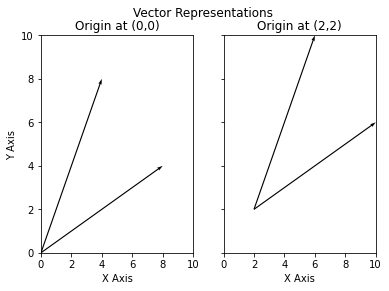

In [31]:
fig, (ax1, ax2) = plt.subplots(1, 2, sharey=True)
fig.suptitle('Vector Representations')

ax1.quiver([0, 0], [0, 0], [4, 8], [8, 4], angles='xy', scale_units='xy', scale=1)
ax1.set_xlim(0, 10)
ax1.set_ylim(0, 10)
ax1.set_title("Origin at (0,0)")

ax2.quiver([2, 2], [2, 2], [4, 8], [8, 4], angles='xy', scale_units='xy', scale=1)
ax2.set_xlim(0, 10)
ax2.set_ylim(0, 10)
ax2.set_title("Origin at (2,2)")

for axs in fig.get_axes():
    axs.set(xlabel='X Axis', ylabel='Y Axis')
    axs.label_outer()

plt.show()

Vector addition can be visualized with the arrow representation.

When a vector is multiplied or scaled by a scalar $\alpha$, we simply multiply each element of the vector with $\alpha$.
$$
\alpha\langle v_{1}, v_{1}, ..., v_{n}\rangle = \langle \alpha v_{1}, \alpha v_{1}, ..., \alpha v_{n}\rangle
$$

In [41]:
def scaleVec(v, s):
    """
    Scales vector v with scalar s.
    """
    return [elem * s for elem in v]

Scalar multiplication maintains *associativity*, which means $\alpha(\beta v) = (\alpha \beta)v$. Scalar bigger than 1 will return vectors larger than the original one. Negative scalar will return vectors in the opposite direction. If we multiply a vector $v$ with all the scaler $\alpha \in R$, it forms a line that go through the origin and vector $v$. In the following graph, vector $\langle1,1\rangle$ is multiplied by $\alpha$ ranging from 0 to 100, which forms a line through the vector and the origin.

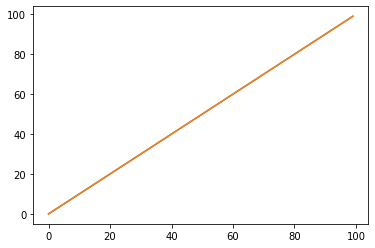

In [61]:
plt.plot([scaleVec([1, 1], i) for i in range(100)])

Addition and scalar multiplication is *distributive*, which means that $\alpha(u + v) = \alpha u + \alpha b$.

## Convex & Affine Combinations

Suppose we want the set of all points making up the line from $\langle 0.5, 1 \rangle$ to $\langle 3.5, 3 \rangle$. We can represent the set of points as $\{ \alpha\langle 3, 2 \rangle + \langle 0.5, 1 \rangle: \alpha \in R, 0 \le \alpha \le 1 \}$. But this equation is not symmetric to both end points of the line segment.

Rather we can use the distributive property to derive new formula:
$$
\alpha\langle 3, 2 \rangle + \langle 0.5, 1 \rangle\\
= \alpha(\langle 3.5, 3 \rangle - \langle 0.5, 1 \rangle) + \langle 0.5, 1 \rangle\\
= \alpha\langle 3.5, 3 \rangle - \alpha\langle 0.5, 1 \rangle + \langle 0.5, 1 \rangle\\
= \alpha\langle 3.5, 3 \rangle + (1 - \alpha)\langle 0.5, 1 \rangle\\
= \alpha\langle 3.5, 3 \rangle + \beta\langle 0.5, 1 \rangle\\
$$
where $\beta = 1 - \alpha$. Now the set of all possible points is $\{\alpha\langle 3.5, 3 \rangle + \beta\langle 0.5, 1 \rangle, \alpha,\beta \in R, 0 \le \alpha,\beta \le 1, \alpha + \beta = 1 \}$. This form is symmetric to both end points. This form of $\alpha.u + \beta.v$ is known as convex combination of $u$ and $v$. The line segment $u$ to $v$ consists of the set of convex combinations of $u$ and $v$. We can use convex combinations of not only line segments but also other objects like images too. We can utilize the parameter $\alpha$ to give weight to certain image while merging it with another.


If we want to take an infinite line throw these vector, we need to take all the affine combinations of $u$ and $v$. To that, we just have to remove the $0 \le \alpha,\beta \le 1$ condition from the set of convex combinations, so that it can vary in each direction infinitely.

## Dot Product

Dot product of two vectors $u$ and $v$ is given by:
$$
\langle u_{1}, u_{1}, ..., u_{n}\rangle . \langle v_{1}, v_{1}, ..., v_{n}\rangle = u_{1}\times v_{1} + u_{2}\times v_{2} + ... + u_{n}\times v_{n}
$$

In [62]:
def dotVec(u, v):
    """
    Calculates dot product between two vectors.
    """
    assert len(u) == len(v), "Vectors have unequal lengths!"
    return sum([a*b for (a, b) in zip(u, v)])

Applications of dot product:
1. Computing total cost or benifit. Suppose $\langle 12, 11, 5, 7 \rangle$ represents the cost of 4 items and $\langle 1, 2, 1, 3 \rangle$ represents the amount bought. Then we can compute their dot product which is $12 \times 1 + 11 \times 2 + 5 \times 1 + 7 \times 3 = 60$, which is the total cost.
2. Dot products are used in linear equations. For example, linear equations have the form of $a.x = \beta$ where $a$ is a vector, $x$ is the vector of variables, and $\beta$ is a scalar. Question is, given equations like $a_{1}.x = \beta_{1}$, $a_{2}.x = \beta_{2}$, ..., $a_{n}.x = \beta_{n}$, can we solve for $x$?.
3. We can measure similarity between two vectors. For example $\langle 1, -1, 0, 1\rangle$ represents voting record of someone and $\langle 1, 0, -1, -1\rangle$ represent that of another one. Here, 0 means neutral, 1 means positive, and -1 means negative vote. Now, if we take dot product of both, similar voting record will have higher values and different records will have values more towards negative. We can do the similar thing to find audio samples within large audio clip by comparing dot products at different positions.

## Backward Substitution

When a system of linear equations is in triangular form, we can back substitue and solve for each variable from the bottom. A triangular system has zeros in all the values below the leading diagonal. For example, a triangular form of a system of linear equations is given below:
$$
5x_{1} + 3x_{2} + 2x_{3} + x_{4} = 4\\
0 + x_{2} + 4x_{3} + 3x_{4} = 12\\
0 + 0 + x_{3} + 2x_{4} = 8\\
0 + 0 + 0 + 2x_{4} = 4
$$
Now we can start solving from the last equation where $x_{4} = 2$. We can plug that value into the one above it to get the value of $x_{3}$, and so on.

In [9]:
def solveTriangular(eqs):
    NotImplemented